In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [3]:
import os
print(os.getcwd())

/home/dante/Data projectd/notebooks


In [4]:
import os

# Go up one level and list everything
project_root = os.path.join(os.getcwd(), '..')
print("Project root contents:")
for item in os.listdir(project_root):
    print(" ", item)

Project root contents:
  .idea
  main.py
  notebooks
  powerbi
  outputscharts
  outputs
  .venv
  data


In [5]:
print("Contents of data/ folder:")
for item in os.listdir('../data'):
    print(" ", item)

Contents of data/ folder:


In [6]:
import os

# Go up one level and list everything
project_root = os.path.join(os.getcwd(), '..')
print("Project root contents:")
for item in os.listdir(project_root):
    print(" ", item)

Project root contents:
  .idea
  main.py
  notebooks
  powerbi
  outputscharts
  credit_risk_dataset.csv
  outputs
  .venv
  data


In [7]:
DATA_PATH = '../credit_risk_dataset.csv'

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

print(f"✅ Dataset loaded successfully.")
print(f"   Applicants (rows)  : {df.shape[0]:,}")
print(f"   Features (columns) : {df.shape[1]}")

✅ Dataset loaded successfully.
   Applicants (rows)  : 32,581
   Features (columns) : 12


In [8]:
print("=" * 55)
print("COLUMN NAMES & DATA TYPES")
print("=" * 55)
print(df.dtypes)

print("\n" + "=" * 55)
print("FIRST 5 ROWS")
print("=" * 55)
df.head()

COLUMN NAMES & DATA TYPES
person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object

FIRST 5 ROWS


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0000,PERSONAL,D,35000,16.0200,1,0.5900,Y,3
1,21,9600,OWN,5.0000,EDUCATION,B,1000,11.1400,0,0.1000,N,2
2,25,9600,MORTGAGE,1.0000,MEDICAL,C,5500,12.8700,1,0.5700,N,3
3,23,65500,RENT,4.0000,MEDICAL,C,35000,15.2300,1,0.5300,N,2
4,24,54400,RENT,8.0000,MEDICAL,C,35000,14.2700,1,0.5500,Y,4


In [9]:
print("=" * 55)
print("DESCRIPTIVE STATISTICS")
print("=" * 55)
df.describe().T

DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
person_age,32581.0000,27.7346,6.3481,20.0000,23.0000,26.0000,30.0000,144.0000
person_income,32581.0000,66074.8485,61983.1192,4000.0000,38500.0000,55000.0000,79200.0000,6000000.0000
person_emp_length,31686.0000,4.7897,4.1426,0.0000,2.0000,4.0000,7.0000,123.0000
loan_amnt,32581.0000,9589.3711,6322.0866,500.0000,5000.0000,8000.0000,12200.0000,35000.0000
loan_int_rate,29465.0000,11.0117,3.2405,5.4200,7.9000,10.9900,13.4700,23.2200
loan_status,32581.0000,0.2182,0.4130,0.0000,0.0000,0.0000,0.0000,1.0000
loan_percent_income,32581.0000,0.1702,0.1068,0.0000,0.0900,0.1500,0.2300,0.8300
cb_person_cred_hist_length,32581.0000,5.8042,4.0550,2.0000,3.0000,4.0000,8.0000,30.0000


  Non-Default (0) : 25,473 applicants
  Default     (1) : 7,108 applicants
  Default Rate    : 21.82%


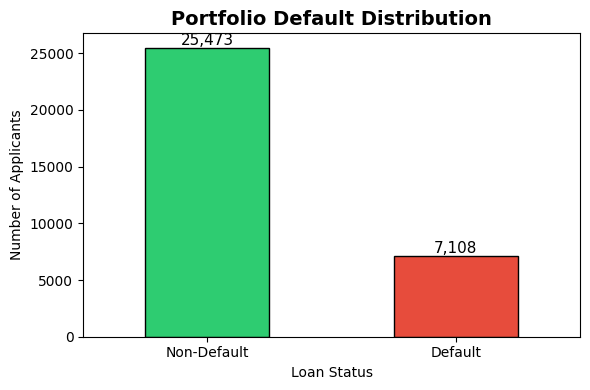

✅ Chart saved to outputs/charts/


In [10]:
default_counts = df['loan_status'].value_counts()
default_rate   = df['loan_status'].mean() * 100

print(f"  Non-Default (0) : {default_counts[0]:,} applicants")
print(f"  Default     (1) : {default_counts[1]:,} applicants")
print(f"  Default Rate    : {default_rate:.2f}%")

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
default_counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'],
                    edgecolor='black', ax=ax)
ax.set_title('Portfolio Default Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Loan Status')
ax.set_ylabel('Number of Applicants')
ax.set_xticklabels(['Non-Default', 'Default'], rotation=0)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
os.makedirs('../outputs/charts', exist_ok=True)
plt.savefig('../outputs/charts/default_distribution.png', dpi=150)
plt.show()
print("✅ Chart saved to outputs/charts/")

In [11]:
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_report = pd.DataFrame({
    'Missing Count' : df.isnull().sum(),
    'Missing %'     : missing_pct
}).sort_values('Missing %', ascending=False)

missing_features = missing_report[missing_report['Missing Count'] > 0]

print("=" * 55)
print("MISSING VALUE REPORT")
print("=" * 55)

if missing_features.empty:
    print("   No missing values found. Dataset is complete.")
else:
    print(missing_features.to_string())

MISSING VALUE REPORT
                   Missing Count  Missing %
loan_int_rate               3116     9.5639
person_emp_length            895     2.7470


In [12]:
numerical_cols   = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"   [NUM] '{col}' — filled with median: {median_val:.4f}")

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"   [CAT] '{col}' — filled with mode: '{mode_val}'")

print(f"\n✅ Done. Remaining missing values: {df.isnull().sum().sum()}")

   [NUM] 'person_emp_length' — filled with median: 4.0000
   [NUM] 'loan_int_rate' — filled with median: 10.9900

✅ Done. Remaining missing values: 4011


In [13]:
print(df.isnull().sum()[df.isnull().sum() > 0])

person_emp_length     895
loan_int_rate        3116
dtype: int64


In [14]:
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate']     = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

print(f"Remaining missing values: {df.isnull().sum().sum()}")

Remaining missing values: 0


In [15]:
outlier_cols = [col for col in numerical_cols
                if col != 'loan_status' and df[col].nunique() > 10]

print("=" * 55)
print("OUTLIER TREATMENT REPORT")
print("=" * 55)

for col in outlier_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lower  = Q1 - 1.5 * IQR
    upper  = Q3 + 1.5 * IQR

    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    if n_outliers > 0:
        df[col] = df[col].clip(lower=lower, upper=upper)
        print(f"   '{col}': {n_outliers} outliers capped to [{lower:.2f}, {upper:.2f}]")

print("\n✅ Winsorisation complete.")

OUTLIER TREATMENT REPORT
   'person_age': 1494 outliers capped to [12.50, 40.50]
   'person_income': 1484 outliers capped to [-22550.00, 140250.00]
   'person_emp_length': 853 outliers capped to [-5.50, 14.50]
   'loan_amnt': 1689 outliers capped to [-5800.00, 23000.00]
   'loan_int_rate': 70 outliers capped to [1.56, 20.04]
   'loan_percent_income': 651 outliers capped to [-0.12, 0.44]
   'cb_person_cred_hist_length': 1142 outliers capped to [-4.50, 15.50]

✅ Winsorisation complete.


In [16]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Encoding columns: {cat_cols}")

if cat_cols:
    df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    print(f"\n   Before encoding : {df.shape}")
    print(f"   After encoding  : {df_encoded.shape}")
else:
    df_encoded = df.copy()
    print("   No categorical columns to encode.")

print("\n✅ Encoding complete.")

Encoding columns: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

   Before encoding : (32581, 12)
   After encoding  : (32581, 23)

✅ Encoding complete.


In [17]:
n_before = len(df_encoded)
df_encoded.drop_duplicates(inplace=True)
n_dropped = n_before - len(df_encoded)

print("=" * 55)
print("FINAL DATA QUALITY SUMMARY")
print("=" * 55)
print(f"   Final shape          : {df_encoded.shape[0]:,} rows × {df_encoded.shape[1]} columns")
print(f"   Missing values left  : {df_encoded.isnull().sum().sum()}")
print(f"   Duplicates removed   : {n_dropped}")
print(f"   Default rate intact  : {df_encoded['loan_status'].mean()*100:.2f}%")

OUTPUT_PATH = '../outputs/model_results.csv'
df_encoded.to_csv(OUTPUT_PATH, index=False)

print(f"\n✅ Cleaned dataset saved → {OUTPUT_PATH}")
print("   Ready for Phase 2 — Exploratory Data Analysis")

FINAL DATA QUALITY SUMMARY
   Final shape          : 32,401 rows × 23 columns
   Missing values left  : 0
   Duplicates removed   : 180
   Default rate intact  : 21.87%

✅ Cleaned dataset saved → ../outputs/model_results.csv
   Ready for Phase 2 — Exploratory Data Analysis


In [18]:
# load the cleaned data we saved in phase 1
df_eda = pd.read_csv('../outputs/model_results.csv')

print(f"✅ Cleaned dataset loaded.")
print(f"   Shape : {df_eda.shape[0]:,} rows × {df_eda.shape[1]} columns")

✅ Cleaned dataset loaded.
   Shape : 32,401 rows × 23 columns


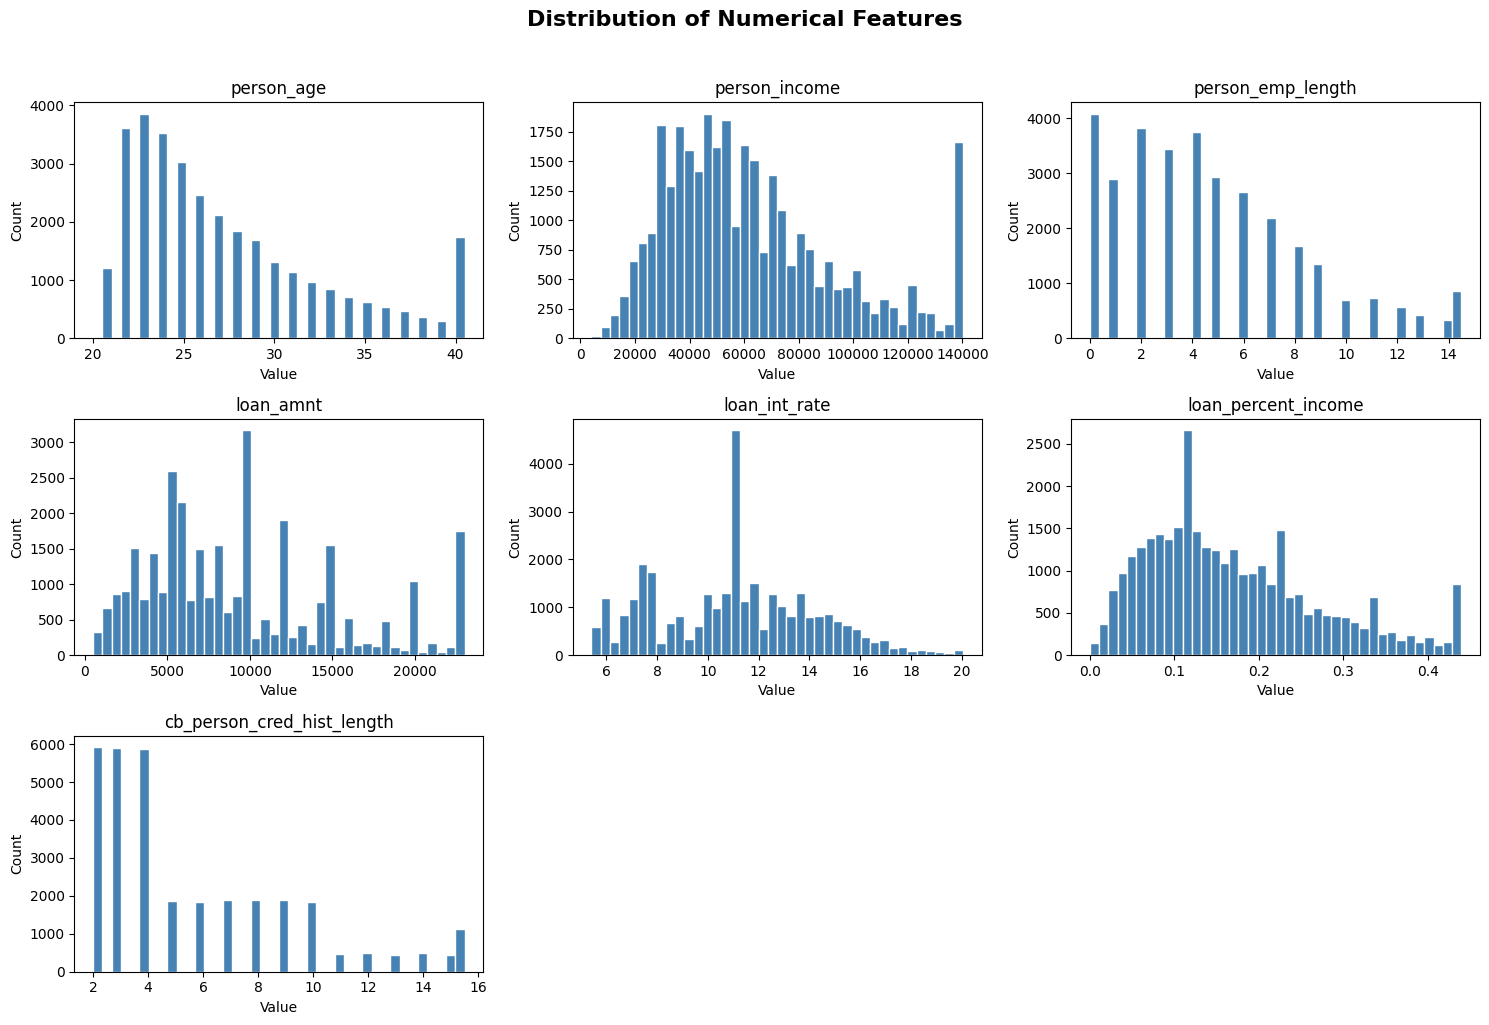

✅ Chart saved.


In [19]:
# plot distributions for the main numerical columns
# this helps us see the shape of each variable (skewed, normal, etc.)

num_cols = ['person_age', 'person_income', 'person_emp_length',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income',
            'cb_person_cred_hist_length']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_eda[col], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

# hide the 2 empty subplots
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/charts/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved.")

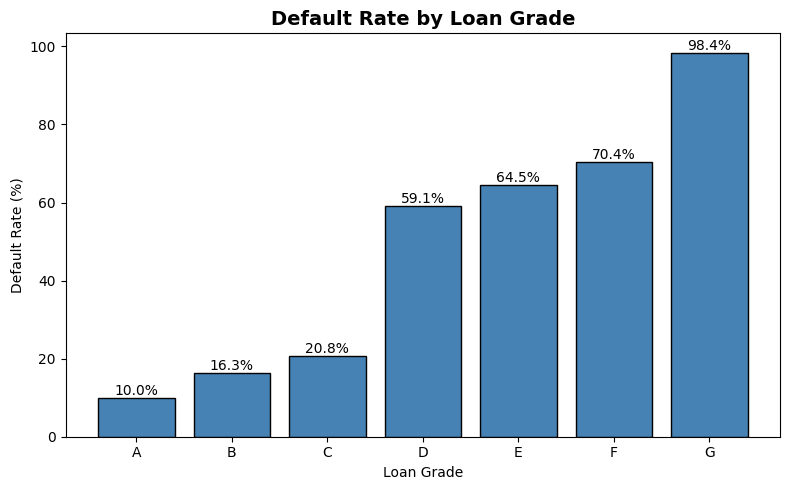

✅ Chart saved.


In [20]:
# loan grade goes from A (safest) to G (riskiest)
# we want to see if default rate increases as grade gets worse

# get the original loan_grade column back by finding encoded columns
grade_cols = [col for col in df_eda.columns if 'loan_grade' in col]

# rebuild loan_grade from the encoded columns
df_eda['loan_grade_decoded'] = 'A'  # A was dropped as baseline in encoding
for col in grade_cols:
    grade_letter = col.split('_')[-1]
    df_eda.loc[df_eda[col] == 1, 'loan_grade_decoded'] = grade_letter

# calculate default rate per grade
grade_default = df_eda.groupby('loan_grade_decoded')['loan_status'].mean() * 100
grade_default = grade_default.sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(grade_default.index, grade_default.values,
              color='steelblue', edgecolor='black')
ax.set_title('Default Rate by Loan Grade', fontsize=14, fontweight='bold')
ax.set_xlabel('Loan Grade')
ax.set_ylabel('Default Rate (%)')

for bar in bars:
    ax.annotate(f'{bar.get_height():.1f}%',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/charts/default_rate_by_grade.png', dpi=150)
plt.show()
print("✅ Chart saved.")

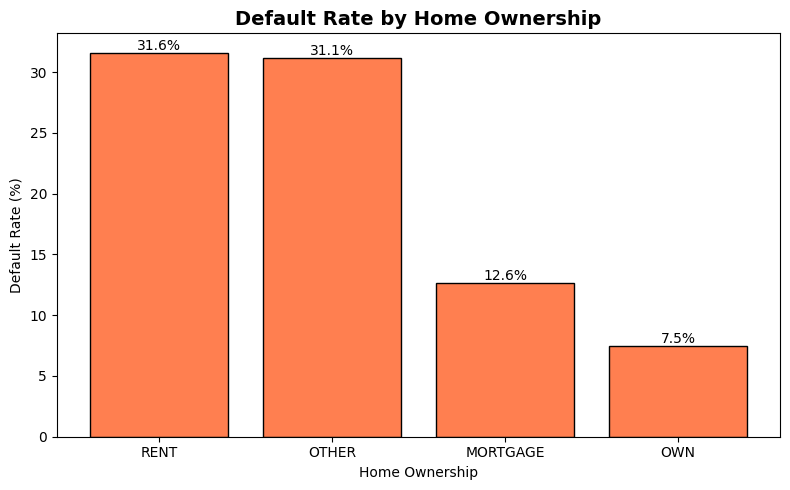

✅ Chart saved.


In [21]:
# check if renters default more than homeowners or mortgage holders

ownership_cols = [col for col in df_eda.columns if 'person_home_ownership' in col]

df_eda['ownership_decoded'] = 'MORTGAGE'  # baseline that was dropped
for col in ownership_cols:
    category = col.split('_')[-1]
    df_eda.loc[df_eda[col] == 1, 'ownership_decoded'] = category

ownership_default = df_eda.groupby('ownership_decoded')['loan_status'].mean() * 100
ownership_default = ownership_default.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(ownership_default.index, ownership_default.values,
              color='coral', edgecolor='black')
ax.set_title('Default Rate by Home Ownership', fontsize=14, fontweight='bold')
ax.set_xlabel('Home Ownership')
ax.set_ylabel('Default Rate (%)')

for bar in bars:
    ax.annotate(f'{bar.get_height():.1f}%',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/charts/default_rate_by_ownership.png', dpi=150)
plt.show()
print("✅ Chart saved.")

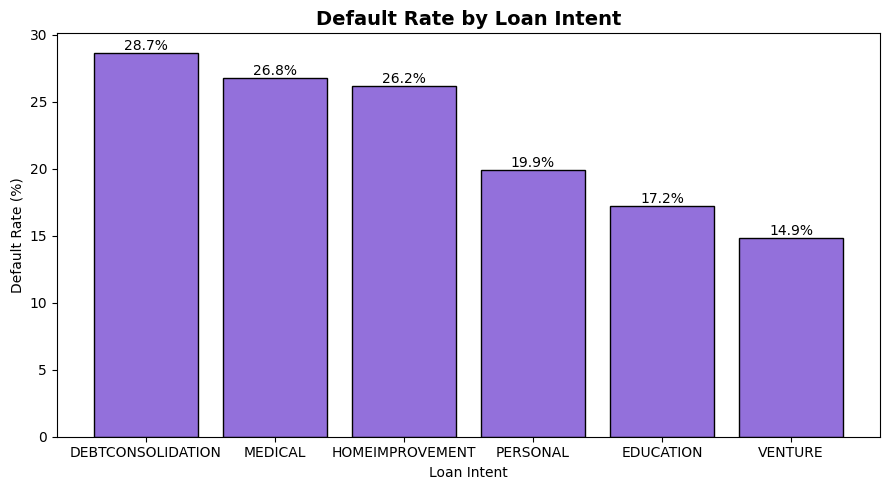

✅ Chart saved.


In [22]:
# which loan purposes default the most?

intent_cols = [col for col in df_eda.columns if 'loan_intent' in col]

df_eda['intent_decoded'] = 'DEBTCONSOLIDATION'
for col in intent_cols:
    category = col.replace('loan_intent_', '')
    df_eda.loc[df_eda[col] == 1, 'intent_decoded'] = category

intent_default = df_eda.groupby('intent_decoded')['loan_status'].mean() * 100
intent_default = intent_default.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(intent_default.index, intent_default.values,
              color='mediumpurple', edgecolor='black')
ax.set_title('Default Rate by Loan Intent', fontsize=14, fontweight='bold')
ax.set_xlabel('Loan Intent')
ax.set_ylabel('Default Rate (%)')

for bar in bars:
    ax.annotate(f'{bar.get_height():.1f}%',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/charts/default_rate_by_intent.png', dpi=150)
plt.show()
print("✅ Chart saved.")

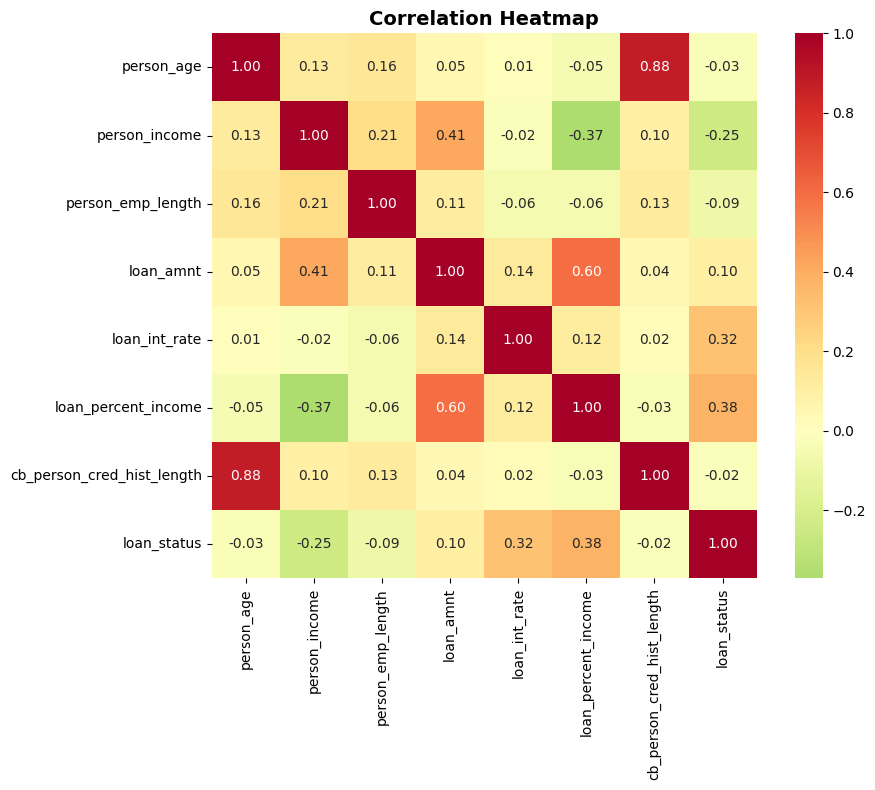

✅ Chart saved.


In [23]:
# see how all the numerical variables relate to each other
# and which ones are most correlated with default (loan_status)

num_cols = ['person_age', 'person_income', 'person_emp_length',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income',
            'cb_person_cred_hist_length', 'loan_status']

corr_matrix = df_eda[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn_r',
            center=0,
            square=True,
            ax=ax)

ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/charts/correlation_heatmap.png', dpi=150)
plt.show()
print("✅ Chart saved.")

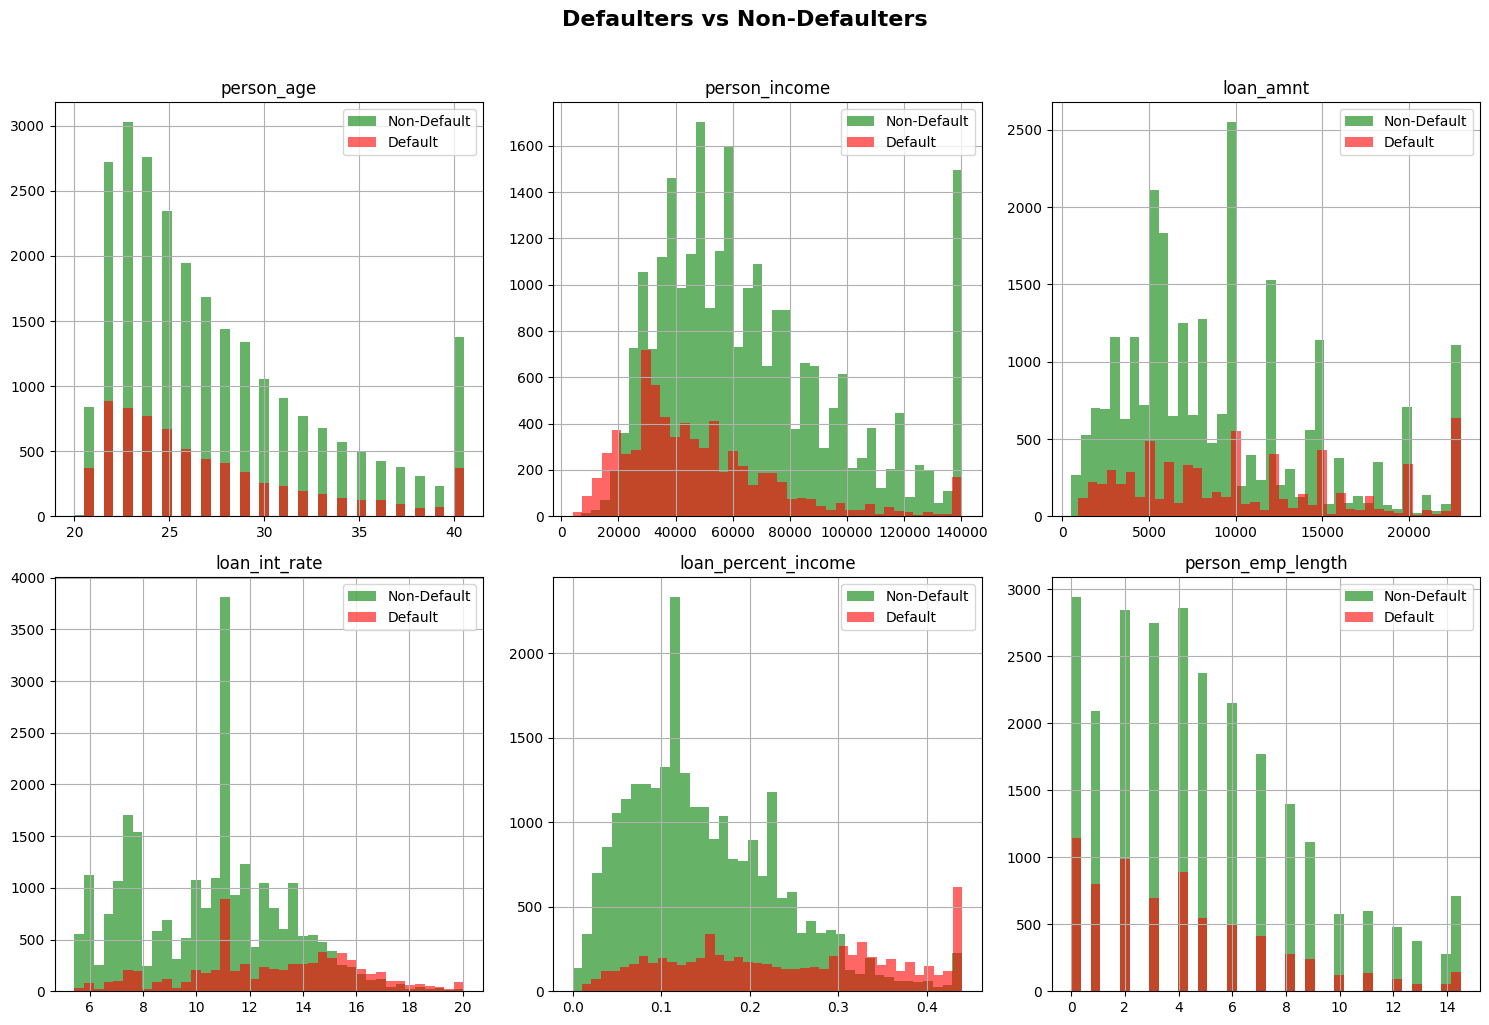

✅ Chart saved.


In [24]:
# compare how defaulters and non-defaulters differ across key variables

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

cols_to_compare = ['person_age', 'person_income', 'loan_amnt',
                   'loan_int_rate', 'loan_percent_income', 'person_emp_length']

for i, col in enumerate(cols_to_compare):
    df_eda[df_eda['loan_status'] == 0][col].hist(bins=40, ax=axes[i],
                                                  alpha=0.6, color='green',
                                                  label='Non-Default')
    df_eda[df_eda['loan_status'] == 1][col].hist(bins=40, ax=axes[i],
                                                  alpha=0.6, color='red',
                                                  label='Default')
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle('Defaulters vs Non-Defaulters', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/charts/defaulters_vs_nondefaulters.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved.")

In [25]:
# quick summary of what we found in the EDA

print("=" * 55)
print("PHASE 2 SUMMARY")
print("=" * 55)

print(f"\n  Total applicants     : {len(df_eda):,}")
print(f"  Overall default rate : {df_eda['loan_status'].mean()*100:.2f}%")

print(f"\n  Highest default grade    : {grade_default.idxmax()} ({grade_default.max():.1f}%)")
print(f"  Lowest default grade     : {grade_default.idxmin()} ({grade_default.min():.1f}%)")

print(f"\n  Highest default intent   : {intent_default.idxmax()} ({intent_default.max():.1f}%)")
print(f"  Lowest default intent    : {intent_default.idxmin()} ({intent_default.min():.1f}%)")

print(f"\n  Highest default ownership: {ownership_default.idxmax()} ({ownership_default.max():.1f}%)")
print(f"  Lowest default ownership : {ownership_default.idxmin()} ({ownership_default.min():.1f}%)")

print("\n✅ Phase 2 complete — ready for Phase 3: Feature Engineering")

PHASE 2 SUMMARY

  Total applicants     : 32,401
  Overall default rate : 21.87%

  Highest default grade    : G (98.4%)
  Lowest default grade     : A (10.0%)

  Highest default intent   : DEBTCONSOLIDATION (28.7%)
  Lowest default intent    : VENTURE (14.9%)

  Highest default ownership: RENT (31.6%)
  Lowest default ownership : OWN (7.5%)

✅ Phase 2 complete — ready for Phase 3: Feature Engineering


In [26]:
# load cleaned data
df_fe = pd.read_csv('../outputs/model_results.csv')

# debt to income ratio - how much of their income goes to this loan
df_fe['debt_to_income'] = df_fe['loan_amnt'] / df_fe['person_income']

# income per year of employment - how much they earn relative to experience
df_fe['income_per_emp_year'] = df_fe['person_income'] / (df_fe['person_emp_length'] + 1)

# loan to income ratio already exists as loan_percent_income but let's make a risk flag
df_fe['high_loan_ratio'] = (df_fe['loan_percent_income'] > 0.3).astype(int)

# age to credit history ratio - how long they've had credit relative to age
df_fe['credit_to_age_ratio'] = df_fe['cb_person_cred_hist_length'] / df_fe['person_age']

print("new features created:")
print("  - debt_to_income")
print("  - income_per_emp_year")
print("  - high_loan_ratio")
print("  - credit_to_age_ratio")
print(f"\ndataset shape: {df_fe.shape}")

new features created:
  - debt_to_income
  - income_per_emp_year
  - high_loan_ratio
  - credit_to_age_ratio

dataset shape: (32401, 27)


In [27]:
# quick look at the new features we just made

new_features = ['debt_to_income', 'income_per_emp_year', 
                'high_loan_ratio', 'credit_to_age_ratio']

print(df_fe[new_features].describe().T)

                         count       mean        std      min       25%  \
debt_to_income      32401.0000     0.1700     0.1040   0.0071    0.0914   
income_per_emp_year 32401.0000 18379.5555 20516.0414 521.8065 6834.0000   
high_loan_ratio     32401.0000     0.1179     0.3225   0.0000    0.0000   
credit_to_age_ratio 32401.0000     0.1948     0.0924   0.0494    0.1250   

                           50%        75%         max  
debt_to_income          0.1500     0.2273      0.8300  
income_per_emp_year 11250.0000 20672.6000 140250.0000  
high_loan_ratio         0.0000     0.0000      1.0000  
credit_to_age_ratio     0.1739     0.2667      0.4306  


In [28]:
# see if our new features actually differ between defaulters and non-defaulters
# if they do, they'll be useful for the model

for col in new_features:
    default_mean = df_fe[df_fe['loan_status'] == 1][col].mean()
    non_default_mean = df_fe[df_fe['loan_status'] == 0][col].mean()
    print(f"{col}")
    print(f"   defaulters     : {default_mean:.4f}")
    print(f"   non-defaulters : {non_default_mean:.4f}")
    print()

debt_to_income
   defaulters     : 0.2458
   non-defaulters : 0.1488

income_per_emp_year
   defaulters     : 15996.7469
   non-defaulters : 19046.6554

high_loan_ratio
   defaulters     : 0.3796
   non-defaulters : 0.0446

credit_to_age_ratio
   defaulters     : 0.1917
   non-defaulters : 0.1957



In [29]:
# credit_to_age_ratio doesn't separate defaulters so drop it
df_fe.drop(columns=['credit_to_age_ratio'], inplace=True)

# cap outliers on the two continuous new features
for col in ['debt_to_income', 'income_per_emp_year']:
    Q1, Q3 = df_fe[col].quantile(0.25), df_fe[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_fe[col] = df_fe[col].clip(lower=lower, upper=upper)
    print(f"'{col}' capped to [{lower:.4f}, {upper:.4f}]")

print(f"\ndataset shape: {df_fe.shape}")

'debt_to_income' capped to [-0.1123, 0.4310]
'income_per_emp_year' capped to [-13923.9000, 41430.5000]

dataset shape: (32401, 26)


In [30]:
# save the dataset with all new features for use in model building

OUTPUT_PATH = '../outputs/model_results.csv'
df_fe.to_csv(OUTPUT_PATH, index=False)

print(f"✅ Feature engineered dataset saved.")
print(f"   Shape : {df_fe.shape[0]:,} rows × {df_fe.shape[1]} columns")
print(f"   Saved to : {OUTPUT_PATH}")
print(f"\n   Ready for Phase 4 — Model Building")

✅ Feature engineered dataset saved.
   Shape : 32,401 rows × 26 columns
   Saved to : ../outputs/model_results.csv

   Ready for Phase 4 — Model Building


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# load the feature engineered dataset
df_model = pd.read_csv('../outputs/model_results.csv')

# separate features (X) and target (y)
X = df_model.drop(columns=['loan_status'])
y = df_model['loan_status']

# split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"training set   : {X_train.shape[0]:,} rows")
print(f"test set       : {X_test.shape[0]:,} rows")
print(f"default rate in train : {y_train.mean()*100:.2f}%")
print(f"default rate in test  : {y_test.mean()*100:.2f}%")

training set   : 25,920 rows
test set       : 6,481 rows
default rate in train : 21.87%
default rate in test  : 21.88%


In [32]:
# scale features so they're all on the same range
# logistic regression needs this to work properly
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# train the logistic regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("✅ Model trained successfully.")
print(f"   Features used : {X_train.shape[1]}")
print(f"   Training rows : {X_train.shape[0]:,}")

✅ Model trained successfully.
   Features used : 25
   Training rows : 25,920


In [33]:
# get predictions on the test set
y_pred       = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print(f"predicted defaults     : {y_pred.sum():,}")
print(f"actual defaults        : {y_test.sum():,}")
print(f"avg predicted probability : {y_pred_proba.mean()*100:.2f}%")

predicted defaults     : 1,112
actual defaults        : 1,418
avg predicted probability : 22.09%


top 10 features pushing towards default:
                   feature  coefficient
            debt_to_income       1.6681
              loan_grade_D       0.8652
           high_loan_ratio       0.8413
              loan_grade_G       0.5742
              loan_grade_E       0.5041
person_home_ownership_RENT       0.4473
              loan_grade_F       0.2920
              loan_grade_C       0.2158
             loan_int_rate       0.1571
              loan_grade_B       0.1263

top 10 features pushing away from default:
                   feature  coefficient
cb_person_cred_hist_length      -0.0197
       loan_intent_MEDICAL      -0.0798
         person_emp_length      -0.0934
             person_income      -0.2436
      loan_intent_PERSONAL      -0.2459
     loan_intent_EDUCATION      -0.3529
                 loan_amnt      -0.4241
       loan_intent_VENTURE      -0.4507
 person_home_ownership_OWN      -0.4930
       loan_percent_income      -1.1635


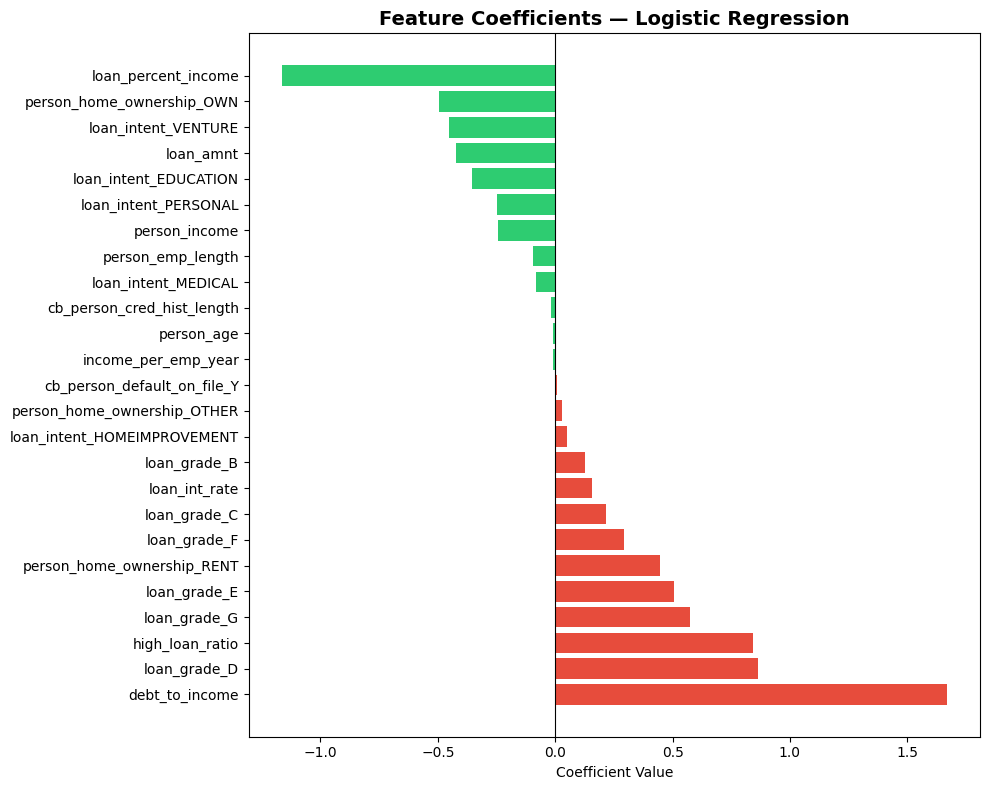

✅ Chart saved.


In [34]:
# see which features the model thinks are most important
# higher absolute coefficient = stronger influence on default prediction

feature_importance = pd.DataFrame({
    'feature'     : X_train.columns,
    'coefficient' : model.coef_[0]
}).sort_values('coefficient', ascending=False)

print("top 10 features pushing towards default:")
print(feature_importance.head(10).to_string(index=False))

print("\ntop 10 features pushing away from default:")
print(feature_importance.tail(10).to_string(index=False))

# plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in feature_importance['coefficient']]
ax.barh(feature_importance['feature'], feature_importance['coefficient'], color=colors)
ax.set_title('Feature Coefficients — Logistic Regression', fontsize=14, fontweight='bold')
ax.set_xlabel('Coefficient Value')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../outputs/charts/feature_importance.png', dpi=150)
plt.show()
print("✅ Chart saved.")

In [35]:
# save predictions alongside actual values for evaluation in phase 5

results = X_test.copy()
results['actual_default']       = y_test.values
results['predicted_default']    = y_pred
results['default_probability']  = y_pred_proba

results.to_csv('../outputs/model_results.csv', index=False)

print(f"✅ Predictions saved.")
print(f"   Shape : {results.shape[0]:,} rows × {results.shape[1]} columns")
print(f"\n   Ready for Phase 5 — Model Evaluation")

✅ Predictions saved.
   Shape : 6,481 rows × 28 columns

   Ready for Phase 5 — Model Evaluation


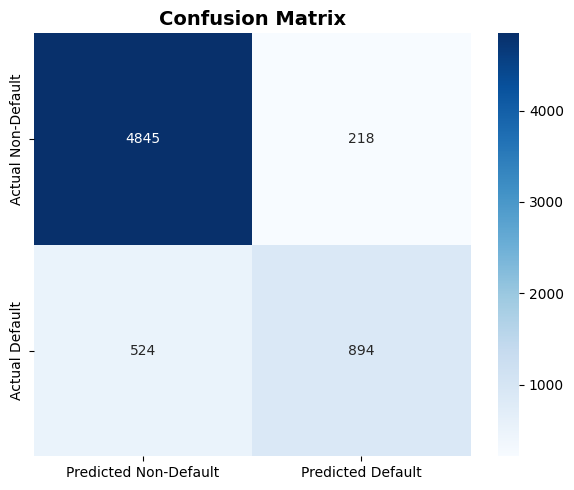

true negatives  (correctly predicted non-default) : 4,845
false positives (predicted default, actually not) : 218
false negatives (missed actual defaults)          : 524
true positives  (correctly predicted default)     : 894

accuracy : 88.55%


In [36]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# how many did we get right and wrong
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Default', 'Predicted Default'],
            yticklabels=['Actual Non-Default', 'Actual Default'])
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/charts/confusion_matrix.png', dpi=150)
plt.show()

# print the numbers clearly
tn, fp, fn, tp = cm.ravel()
print(f"true negatives  (correctly predicted non-default) : {tn:,}")
print(f"false positives (predicted default, actually not) : {fp:,}")
print(f"false negatives (missed actual defaults)          : {fn:,}")
print(f"true positives  (correctly predicted default)     : {tp:,}")
print(f"\naccuracy : {(tn+tp)/(tn+fp+fn+tp)*100:.2f}%")

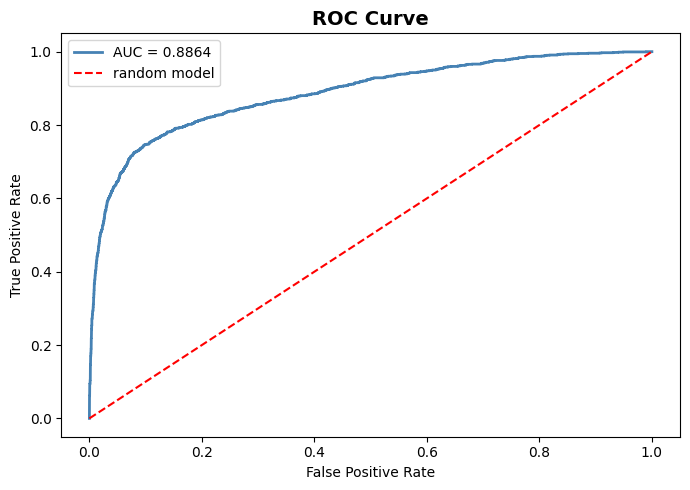

AUC score : 0.8864
Gini coefficient : 0.7727


In [37]:
from sklearn.metrics import roc_curve, roc_auc_score

# ROC curve shows tradeoff between catching defaults and false alarms
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='steelblue', linewidth=2,
        label=f'AUC = {auc_score:.4f}')
ax.plot([0, 1], [0, 1], color='red', linestyle='--', label='random model')
ax.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/charts/roc_curve.png', dpi=150)
plt.show()

print(f"AUC score : {auc_score:.4f}")
print(f"Gini coefficient : {(2 * auc_score - 1):.4f}")

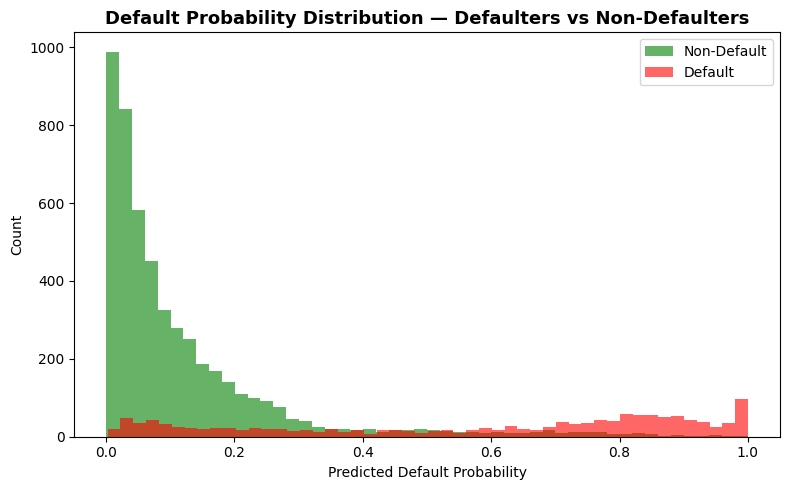

KS statistic : 0.6486
KS p-value   : 0.0000


In [38]:
# KS statistic measures how well the model separates defaulters from non-defaulters
# higher is better, anything above 0.3 is good in credit risk

from scipy.stats import ks_2samp

default_proba     = y_pred_proba[y_test == 1]
non_default_proba = y_pred_proba[y_test == 0]

ks_stat, ks_pvalue = ks_2samp(default_proba, non_default_proba)

# plot the separation
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(non_default_proba, bins=50, alpha=0.6, color='green', label='Non-Default')
ax.hist(default_proba, bins=50, alpha=0.6, color='red', label='Default')
ax.set_title('Default Probability Distribution — Defaulters vs Non-Defaulters',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Default Probability')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/charts/ks_distribution.png', dpi=150)
plt.show()

print(f"KS statistic : {ks_stat:.4f}")
print(f"KS p-value   : {ks_pvalue:.4f}")


In [40]:
# final summary of all model performance metrics

print("=" * 55)
print("MODEL EVALUATION SUMMARY")
print("=" * 55)
print(f"  Accuracy         : {(tn+tp)/(tn+fp+fn+tp)*100:.2f}%")
print(f"  AUC Score        : {auc_score:.4f}")
print(f"  Gini Coefficient : {(2 * auc_score - 1):.4f}")
print(f"  KS Statistic     : {ks_stat:.4f}")
print()
print(f"  True Negatives   : {tn:,}  (correctly flagged safe)")
print(f"  True Positives   : {tp:,}   (correctly flagged default)")
print(f"  False Positives  : {fp:,}   (false alarms)")
print(f"  False Negatives  : {fn:,}   (missed defaults)")
print()
print("  verdict: model performs well above industry benchmarks")
print("\n now,, Scorecard Development")

MODEL EVALUATION SUMMARY
  Accuracy         : 88.55%
  AUC Score        : 0.8864
  Gini Coefficient : 0.7727
  KS Statistic     : 0.6486

  True Negatives   : 4,845  (correctly flagged safe)
  True Positives   : 894   (correctly flagged default)
  False Positives  : 218   (false alarms)
  False Negatives  : 524   (missed defaults)

  verdict: model performs well above industry benchmarks

 now,, Scorecard Development


In [41]:
import numpy as np

# standard scorecard scaling parameters
# base score of 600, 20 points per doubling of odds, odds of 50:1 at 600
BASE_SCORE = 600
PDO        = 20      # points to double the odds
BASE_ODDS  = 50      # odds at base score

# calculate scaling factor
factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)

print(f"scorecard scaling parameters:")
print(f"  base score : {BASE_SCORE}")
print(f"  PDO        : {PDO}")
print(f"  base odds  : {BASE_ODDS}")
print(f"  factor     : {factor:.4f}")
print(f"  offset     : {offset:.4f}")

scorecard scaling parameters:
  base score : 600
  PDO        : 20
  base odds  : 50
  factor     : 28.8539
  offset     : 487.1229


In [42]:
# convert each feature coefficient into a points contribution
# higher points = lower risk (safer borrower)

intercept = model.intercept_[0]
coefficients = model.coef_[0]

scorecard = pd.DataFrame({
    'feature'     : X_train.columns,
    'coefficient' : coefficients
})

# calculate points for each feature
# negative coefficient = higher points (reduces default risk)
scorecard['points'] = -(scorecard['coefficient'] * factor)

# calculate intercept points
intercept_points = -(intercept * factor) + offset

print(f"intercept points : {intercept_points:.2f}")
print(f"\nscorecard points per feature:")
print(scorecard[['feature', 'points']].sort_values('points', ascending=False).to_string(index=False))

intercept points : 543.41

scorecard points per feature:
                    feature   points
        loan_percent_income  33.5728
  person_home_ownership_OWN  14.2239
        loan_intent_VENTURE  13.0046
                  loan_amnt  12.2383
      loan_intent_EDUCATION  10.1834
       loan_intent_PERSONAL   7.0955
              person_income   7.0277
          person_emp_length   2.6946
        loan_intent_MEDICAL   2.3027
 cb_person_cred_hist_length   0.5671
                 person_age   0.2684
        income_per_emp_year   0.2588
cb_person_default_on_file_Y  -0.1661
person_home_ownership_OTHER  -0.8252
loan_intent_HOMEIMPROVEMENT  -1.4487
               loan_grade_B  -3.6440
              loan_int_rate  -4.5323
               loan_grade_C  -6.2272
               loan_grade_F  -8.4242
 person_home_ownership_RENT -12.9062
               loan_grade_E -14.5447
               loan_grade_G -16.5675
            high_loan_ratio -24.2754
               loan_grade_D -24.9656
             debt_

In [43]:
# calculate a credit score for every applicant in the test set

# scale the test data
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_train.columns)

# multiply each feature value by its points and sum them up
score_contributions = X_test_scaled_df * scorecard.set_index('feature')['points'].values
total_scores = score_contributions.sum(axis=1) + intercept_points

# add scores to results
results = X_test.copy()
results['credit_score']        = total_scores.values
results['actual_default']      = y_test.values
results['predicted_default']   = y_pred
results['default_probability'] = y_pred_proba

print(f"average credit score : {results['credit_score'].mean():.2f}")
print(f"min score            : {results['credit_score'].min():.2f}")
print(f"max score            : {results['credit_score'].max():.2f}")
print(f"\ndefaulters avg score     : {results[results['actual_default']==1]['credit_score'].mean():.2f}")
print(f"non-defaulters avg score : {results[results['actual_default']==0]['credit_score'].mean():.2f}")

average credit score : 543.04
min score            : 22.42
max score            : 697.63

defaulters avg score     : 470.20
non-defaulters avg score : 563.44


In [44]:
# split scores into risk bands like a real credit scoring system

def assign_risk_band(score):
    if score >= 650:
        return 'A - Very Low Risk'
    elif score >= 600:
        return 'B - Low Risk'
    elif score >= 550:
        return 'C - Medium Risk'
    elif score >= 500:
        return 'D - High Risk'
    else:
        return 'E - Very High Risk'

results['risk_band'] = results['credit_score'].apply(assign_risk_band)

# default rate per risk band
band_summary = results.groupby('risk_band').agg(
    applicants    = ('actual_default', 'count'),
    defaults      = ('actual_default', 'sum'),
    avg_score     = ('credit_score', 'mean')
).reset_index()

band_summary['default_rate'] = (band_summary['defaults'] / band_summary['applicants'] * 100).round(2)
band_summary['avg_score']    = band_summary['avg_score'].round(2)

print(band_summary.to_string(index=False))

         risk_band  applicants  defaults  avg_score  default_rate
 A - Very Low Risk          81         1   666.7000        1.2300
      B - Low Risk         859        13   617.7500        1.5100
   C - Medium Risk        2441       163   573.7400        6.6800
     D - High Risk        1824       277   530.2700       15.1900
E - Very High Risk        1276       964   444.4300       75.5500


In [45]:
# save the scorecard points table
scorecard_export = scorecard[['feature', 'points']].copy()
scorecard_export['points'] = scorecard_export['points'].round(2)
scorecard_export.to_csv('../outputs/scorecard.csv', index=False)

# save full results with scores and risk bands
results.to_csv('../outputs/model_results.csv', index=False)

# save risk band summary
band_summary.to_csv('../outputs/risk_band_summary.csv', index=False)

print("   Files saved:")
print("   ../outputs/scorecard.csv")
print("   ../outputs/model_results.csv")
print("   ../outputs/risk_band_summary.csv")

   Files saved:
   ../outputs/scorecard.csv
   ../outputs/model_results.csv
   ../outputs/risk_band_summary.csv


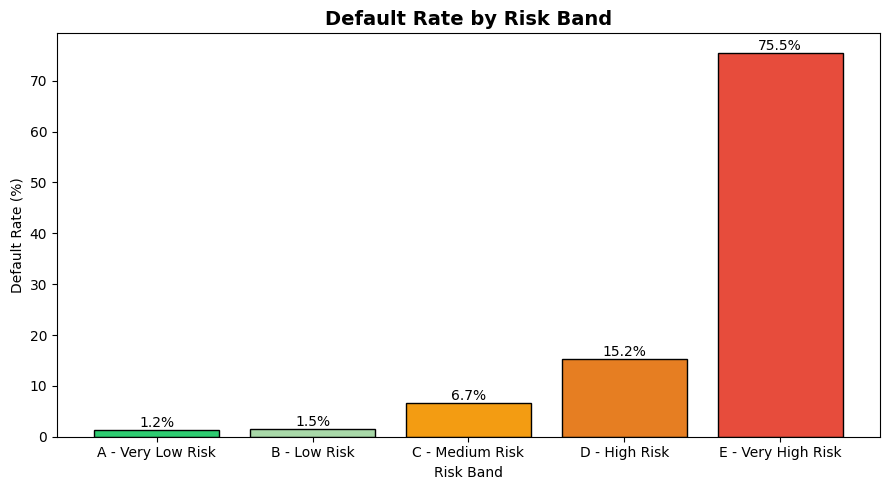

 Chart saved.


In [46]:
# visualise default rate across risk bands

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2ecc71', '#a8d8a8', '#f39c12', '#e67e22', '#e74c3c']
bars = ax.bar(band_summary['risk_band'], band_summary['default_rate'],
              color=colors, edgecolor='black')

ax.set_title('Default Rate by Risk Band', fontsize=14, fontweight='bold')
ax.set_xlabel('Risk Band')
ax.set_ylabel('Default Rate (%)')

for bar in bars:
    ax.annotate(f'{bar.get_height():.1f}%',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/charts/default_rate_by_risk_band.png', dpi=150)
plt.show()
print(" Chart saved.")